In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("hotel_bookings.csv")

In [4]:
df.shape

(119390, 32)

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [8]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [9]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [10]:
missing=pd.DataFrame({

"Missing Values":df.isnull().sum(),

"Percentage":round(df.isnull().mean()*100,2)

})

missing.sort_values("Percentage",ascending=False)

,Missing Values,Percentage
company,112593,94.31
agent,16340,13.69
country,488,0.41
hotel,0,0.00
arrival_date_month,0,0.00
arrival_date_week_number,0,0.00
lead_time,0,0.00
is_canceled,0,0.00
stays_in_weekend_nights,0,0.00
stays_in_week_nights,0,0.00


In [11]:
df.duplicated().sum()

np.int64(31994)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.shape

(87396, 32)

In [14]:
df['children'].fillna(
df['children'].median(),
inplace=True
)

In [15]:
df['country'].fillna(
df['country'].mode()[0],
inplace=True
)


In [16]:
df['agent'].fillna(0,inplace=True)

In [17]:
df['company'].fillna(0,inplace=True)

In [18]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [19]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,63371
1,24025


In [20]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,0.274898,79.891368,2016.210296,26.838334,15.815541,1.005263,2.625395,1.875795,0.138633,0.010824,0.039075,0.030413,0.183990,0.271603,81.004657,11.016809,0.749565,106.337246,0.084226,0.698567
std,0.446466,86.052325,0.686102,13.674572,8.835146,1.031921,2.053584,0.626500,0.455871,0.113597,0.193775,0.369145,1.731894,0.727245,109.945638,54.047484,10.015731,55.013953,0.281533,0.831946
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,0.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [21]:
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,87396,87396,87396,87396,87396,87396,87396,87396,87396,87396,87396,87396
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2016-02-14
freq,53428,11257,67978,27905,51618,69141,56552,46313,86251,71986,63371,211


In [22]:
df.nunique()

,0
hotel,2
is_canceled,2
lead_time,479
arrival_date_year,3
arrival_date_month,12
arrival_date_week_number,53
arrival_date_day_of_month,31
stays_in_weekend_nights,17
stays_in_week_nights,35
adults,14


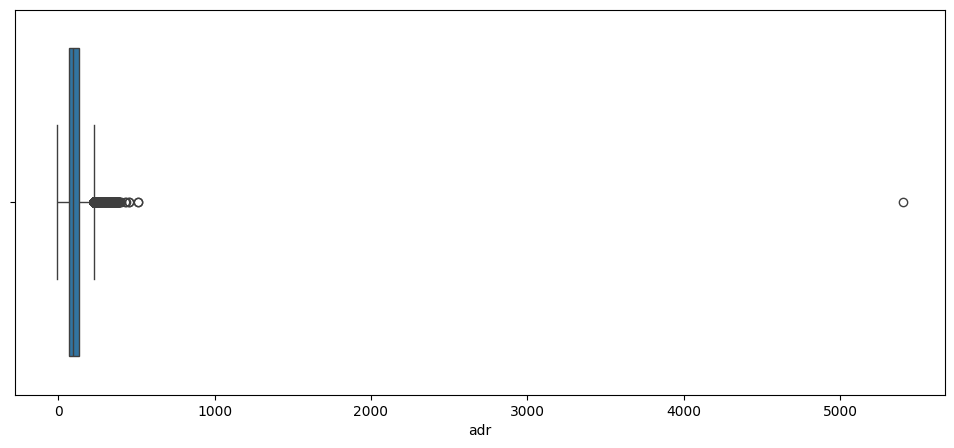

In [23]:
plt.figure(figsize=(12,5))

sns.boxplot(x=df['adr'])

plt.show()

In [24]:
Q1=df['adr'].quantile(.25)

Q3=df['adr'].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

df=df[
(df['adr']>=lower)&
(df['adr']<=upper)
]

In [25]:
df.shape

(84906, 32)

In [26]:
df['arrival_date_month'].value_counts()


,count
arrival_date_month,
August,9869
July,9491
May,8237
April,7834
June,7613
March,7488
October,6906
September,6619
February,6087


In [27]:
df['meal'].value_counts()

,count
meal,
BB,66468
SC,9481
HB,8204
Undefined,457
FB,296


In [28]:
df['hotel'].value_counts()

,count
hotel,
City Hotel,52651
Resort Hotel,32255


In [29]:
df.to_csv(
"hotel_bookings_cleaned.csv",
index=False
)

In [30]:
from google.colab import files

files.download(
"hotel_bookings_cleaned.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
print(df.shape)

(84906, 32)


In [32]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("hotel_booking.db")

df.to_sql(
    "hotel_bookings",
    conn,
    if_exists="replace",
    index=False
)

84906

In [33]:
query="""
SELECT COUNT(*) AS Total_Bookings
FROM hotel_bookings;
"""

pd.read_sql(query,conn)

,Total_Bookings
0,84906


In [34]:
query="""
SELECT COUNT(DISTINCT hotel) AS Hotel_Types
FROM hotel_bookings;
"""

pd.read_sql(query,conn)

,Hotel_Types
0,2


In [35]:
query="""
SELECT

hotel,

COUNT(*) Total_Bookings

FROM hotel_bookings

GROUP BY hotel

ORDER BY Total_Bookings DESC;
"""

pd.read_sql(query,conn)

,hotel,Total_Bookings
0,City Hotel,52651
1,Resort Hotel,32255


In [36]:
query="""
SELECT

is_canceled,

COUNT(*) Total

FROM hotel_bookings

GROUP BY is_canceled;
"""

pd.read_sql(query,conn)

,is_canceled,Total
0,0,61846
1,1,23060


In [37]:
query="""
SELECT

ROUND(
AVG(is_canceled)*100,2
) Cancellation_Rate
FROM hotel_bookings;
"""

pd.read_sql(query,conn)

,Cancellation_Rate
0,27.16


In [38]:
query="""
SELECT

arrival_date_month,

COUNT(*) Bookings

FROM hotel_bookings

GROUP BY arrival_date_month

ORDER BY Bookings DESC;
"""

pd.read_sql(query,conn)

,arrival_date_month,Bookings
0,August,9869
1,July,9491
2,May,8237
3,April,7834
4,June,7613
5,March,7488
6,October,6906
7,September,6619
8,February,6087
9,December,5083


In [39]:
query="""
SELECT

country,

COUNT(*) Bookings

FROM hotel_bookings

GROUP BY country

ORDER BY Bookings DESC

LIMIT 10;
"""

pd.read_sql(query,conn)

,country,Bookings
0,PRT,27033
1,GBR,10253
2,FRA,8642
3,ESP,6790
4,DEU,5334
5,ITA,2994
6,IRL,2981
7,BEL,2048
8,BRA,1956
9,NLD,1880


In [40]:
query="""
SELECT

customer_type,

COUNT(*) Customers

FROM hotel_bookings

GROUP BY customer_type;
"""

pd.read_sql(query,conn)

,customer_type,Customers
0,Contract,3137
1,Group,534
2,Transient,69653
3,Transient-Party,11582


In [41]:
query="""
SELECT

market_segment,

COUNT(*) Total

FROM hotel_bookings

GROUP BY market_segment

ORDER BY Total DESC;
"""

pd.read_sql(query,conn)

,market_segment,Total
0,Online TA,49844
1,Offline TA/TO,13838
2,Direct,11169
3,Groups,4916
4,Corporate,4208
5,Complementary,702
6,Aviation,227
7,Undefined,2


In [42]:
query="""
SELECT

distribution_channel,

COUNT(*) Total

FROM hotel_bookings

GROUP BY distribution_channel;
"""

pd.read_sql(query,conn)

,distribution_channel,Total
0,Corporate,5076
1,Direct,12345
2,GDS,181
3,TA/TO,67299
4,Undefined,5


In [43]:
query="""
SELECT

deposit_type,

COUNT(*) Total

FROM hotel_bookings

GROUP BY deposit_type;
"""

pd.read_sql(query,conn)

,deposit_type,Total
0,No Deposit,83768
1,Non Refund,1033
2,Refundable,105


In [44]:
query="""
SELECT

ROUND(
AVG(adr),2
) Average_ADR

FROM hotel_bookings;
"""

pd.read_sql(query,conn)

,Average_ADR
0,101.78


In [45]:
query="""
SELECT

MAX(adr) Highest_ADR

FROM hotel_bookings;
"""

pd.read_sql(query,conn)

,Highest_ADR
0,227.0


In [46]:
query="""
SELECT

MIN(adr) Lowest_ADR

FROM hotel_bookings;
"""

pd.read_sql(query,conn)

,Lowest_ADR
0,-6.38


In [47]:
query="""
SELECT

hotel,

ROUND(
AVG(adr),2
) Avg_ADR

FROM hotel_bookings

GROUP BY hotel;
"""

pd.read_sql(query,conn)

,hotel,Avg_ADR
0,City Hotel,108.78
1,Resort Hotel,90.34


In [48]:
query="""
SELECT

ROUND(
AVG(lead_time),2
) Avg_Lead_Time

FROM hotel_bookings;
"""

pd.read_sql(query,conn)

,Avg_Lead_Time
0,80.14


In [49]:
query="""
SELECT

hotel,

ROUND(
AVG(lead_time),2
) Avg_Lead_Time

FROM hotel_bookings

GROUP BY hotel;
"""

pd.read_sql(query,conn)

,hotel,Avg_Lead_Time
0,City Hotel,78.05
1,Resort Hotel,83.54


In [50]:
query="""
SELECT

is_repeated_guest,

COUNT(*) Guests

FROM hotel_bookings

GROUP BY is_repeated_guest;
"""

pd.read_sql(query,conn)

,is_repeated_guest,Guests
0,0,81529
1,1,3377


In [51]:
query="""
SELECT

meal,

COUNT(*) Total

FROM hotel_bookings

GROUP BY meal;
"""

pd.read_sql(query,conn)

,meal,Total
0,BB,66468
1,FB,296
2,HB,8204
3,SC,9481
4,Undefined,457


In [52]:
query="""
SELECT

reserved_room_type,

COUNT(*) Rooms

FROM hotel_bookings

GROUP BY reserved_room_type;
"""

pd.read_sql(query,conn)

,reserved_room_type,Rooms
0,A,56240
1,B,990
2,C,741
3,D,17001
4,E,5682
5,F,2347
6,G,1472
7,H,421
8,L,6
9,P,6


In [53]:
query="""
SELECT

assigned_room_type,

COUNT(*) Rooms

FROM hotel_bookings

GROUP BY assigned_room_type;
"""

pd.read_sql(query,conn)

,assigned_room_type,Rooms
0,A,46036
1,B,1805
2,C,1977
3,D,22050
4,E,6840
5,F,3149
6,G,1894
7,H,528
8,I,346
9,K,274


In [54]:
query="""
SELECT

ROUND(
AVG(adults),2
) Avg_Adults

FROM hotel_bookings;
"""

pd.read_sql(query,conn)


,Avg_Adults
0,1.87


In [55]:
query="""
SELECT

ROUND(
AVG(children),2
) Avg_Children

FROM hotel_bookings;
"""

pd.read_sql(query,conn)

,Avg_Children
0,0.12


In [56]:
query="""
SELECT

total_of_special_requests,

COUNT(*) Bookings

FROM hotel_bookings

GROUP BY total_of_special_requests

ORDER BY total_of_special_requests;
"""

pd.read_sql(query,conn)

,total_of_special_requests,Bookings
0,0,42815
1,1,28183
2,2,11386
3,3,2197
4,4,292
5,5,33


In [57]:
query="""
SELECT

ROUND(
AVG(stays_in_weekend_nights),2
) Avg_Weekend,

ROUND(
AVG(stays_in_week_nights),2
) Avg_Weekday

FROM hotel_bookings;
"""

pd.read_sql(query,conn)


,Avg_Weekend,Avg_Weekday
0,1.0,2.61


In [58]:
query="""
SELECT

customer_type,

ROUND(AVG(adr),2) AS Avg_ADR

FROM hotel_bookings

GROUP BY customer_type

ORDER BY Avg_ADR DESC;
"""

pd.read_sql(query,conn)

,customer_type,Avg_ADR
0,Transient,105.06
1,Contract,92.66
2,Transient-Party,85.48
3,Group,80.88


In [59]:
query="""
SELECT

market_segment,

ROUND(AVG(adr),2) Avg_ADR

FROM hotel_bookings

GROUP BY market_segment

ORDER BY Avg_ADR DESC;
"""

pd.read_sql(query,conn)

,market_segment,Avg_ADR
0,Online TA,113.21
1,Direct,108.19
2,Aviation,100.17
3,Offline TA/TO,80.72
4,Groups,73.72
5,Corporate,67.90
6,Undefined,15.00
7,Complementary,3.05


In [60]:
query="""
SELECT

distribution_channel,

ROUND(AVG(adr),2) Avg_ADR

FROM hotel_bookings

GROUP BY distribution_channel

ORDER BY Avg_ADR DESC;
"""

pd.read_sql(query,conn)

,distribution_channel,Avg_ADR
0,GDS,120.32
1,TA/TO,104.40
2,Direct,101.00
3,Corporate,68.27
4,Undefined,46.24


In [61]:
query="""
SELECT

country,

ROUND(AVG(adr),2) Avg_ADR

FROM hotel_bookings

GROUP BY country

HAVING COUNT(*)>20

ORDER BY Avg_ADR DESC

LIMIT 10;
"""

pd.read_sql(query,conn)

,country,Avg_ADR
0,PHL,147.71
1,ARE,128.79
2,LBN,128.37
3,URY,127.58
4,HKG,124.46
5,LUX,123.98
6,TWN,123.07
7,IRN,122.62
8,ISR,120.37
9,JPN,120.26


In [62]:
query="""
SELECT

customer_type,

ROUND(AVG(lead_time),2) Avg_Lead_Time

FROM hotel_bookings

GROUP BY customer_type;
"""

pd.read_sql(query,conn)

,customer_type,Avg_Lead_Time
0,Contract,109.26
1,Group,52.44
2,Transient,73.46
3,Transient-Party,113.65


In [63]:
query="""
SELECT

hotel,

adr,

RANK() OVER(

ORDER BY adr DESC

) ADR_Rank

FROM hotel_bookings

LIMIT 30;
"""

pd.read_sql(query,conn)

,hotel,adr,ADR_Rank
0,Resort Hotel,227.00,1
1,Resort Hotel,227.00,1
2,Resort Hotel,227.00,1
3,Resort Hotel,227.00,1
4,Resort Hotel,227.00,1
5,Resort Hotel,227.00,1
6,Resort Hotel,227.00,1
7,Resort Hotel,227.00,1
8,Resort Hotel,227.00,1
9,Resort Hotel,227.00,1


In [64]:
query="""
SELECT

hotel,

adr,

DENSE_RANK() OVER(

ORDER BY adr DESC

) Dense_Rank

FROM hotel_bookings

LIMIT 30;
"""

pd.read_sql(query,conn)

,hotel,adr,Dense_Rank
0,Resort Hotel,227.00,1
1,Resort Hotel,227.00,1
2,Resort Hotel,227.00,1
3,Resort Hotel,227.00,1
4,Resort Hotel,227.00,1
5,Resort Hotel,227.00,1
6,Resort Hotel,227.00,1
7,Resort Hotel,227.00,1
8,Resort Hotel,227.00,1
9,Resort Hotel,227.00,1


In [65]:
query="""
SELECT

hotel,

adr,

ROW_NUMBER() OVER(

ORDER BY adr DESC

) Row_Number

FROM hotel_bookings

LIMIT 30;
"""

pd.read_sql(query,conn)

,hotel,adr,Row_Number
0,Resort Hotel,227.00,1
1,Resort Hotel,227.00,2
2,Resort Hotel,227.00,3
3,Resort Hotel,227.00,4
4,Resort Hotel,227.00,5
5,Resort Hotel,227.00,6
6,Resort Hotel,227.00,7
7,Resort Hotel,227.00,8
8,Resort Hotel,227.00,9
9,Resort Hotel,227.00,10


In [66]:
query="""
SELECT

adr,

NTILE(4) OVER(

ORDER BY adr

) ADR_Quartile

FROM hotel_bookings;
"""

pd.read_sql(query,conn)

,adr,ADR_Quartile
0,-6.38,1
1,0.00,1
2,0.00,1
3,0.00,1
4,0.00,1
...,...,...
84901,227.00,4
84902,227.00,4
84903,227.00,4
84904,227.00,4


In [67]:
query="""
SELECT

adr,

AVG(adr) OVER(

ORDER BY adr

ROWS BETWEEN UNBOUNDED PRECEDING

AND CURRENT ROW

) Running_Avg

FROM hotel_bookings

LIMIT 100;
"""

pd.read_sql(query,conn)

,adr,Running_Avg
0,-6.38,-6.380000
1,0.00,-3.190000
2,0.00,-2.126667
3,0.00,-1.595000
4,0.00,-1.276000
...,...,...
95,0.00,-0.066458
96,0.00,-0.065773
97,0.00,-0.065102
98,0.00,-0.064444


In [68]:
query="""
SELECT

adr,

CASE

WHEN adr<50 THEN 'Low'

WHEN adr BETWEEN 50 AND 100 THEN 'Medium'

WHEN adr BETWEEN 101 AND 150 THEN 'High'

ELSE 'Luxury'

END ADR_Category

FROM hotel_bookings;
"""

pd.read_sql(query,conn)

,adr,ADR_Category
0,0.00,Low
1,0.00,Low
2,75.00,Medium
3,75.00,Medium
4,98.00,Medium
...,...,...
84901,96.14,Medium
84902,225.43,Luxury
84903,157.71,Luxury
84904,104.40,High


In [69]:
query="""
WITH HotelSummary AS(

SELECT

hotel,

COUNT(*) Bookings,

ROUND(AVG(adr),2) AvgADR

FROM hotel_bookings

GROUP BY hotel

)

SELECT *

FROM HotelSummary;
"""

pd.read_sql(query,conn)

,hotel,Bookings,AvgADR
0,City Hotel,52651,108.78
1,Resort Hotel,32255,90.34


In [70]:
query="""
WITH CountrySummary AS(

SELECT

country,

COUNT(*) Bookings,

ROUND(AVG(adr),2) AvgADR

FROM hotel_bookings

GROUP BY country

)

SELECT *

FROM CountrySummary

ORDER BY AvgADR DESC;
"""

pd.read_sql(query,conn)

,country,Bookings,AvgADR
0,UMI,1,200.00
1,LAO,2,181.67
2,NCL,1,175.50
3,FRO,3,165.67
4,GIB,13,157.71
...,...,...,...
170,COM,1,71.61
171,BHS,1,50.85
172,BDI,1,46.00
173,MDG,1,44.00


In [71]:
query="""
SELECT

customer_type,

ROUND(AVG(adr),2) AvgADR,

RANK() OVER(

ORDER BY AVG(adr) DESC

) Rank_No

FROM hotel_bookings

GROUP BY customer_type;
"""

pd.read_sql(query,conn)

,customer_type,AvgADR,Rank_No
0,Transient,105.06,1
1,Contract,92.66,2
2,Transient-Party,85.48,3
3,Group,80.88,4


In [72]:
query="""
SELECT

hotel,

ROUND(AVG(lead_time),2) AvgLeadTime

FROM hotel_bookings

GROUP BY hotel;
"""

pd.read_sql(query,conn)

,hotel,AvgLeadTime
0,City Hotel,78.05
1,Resort Hotel,83.54


In [73]:
query="""
SELECT

hotel,

ROUND(AVG(is_canceled)*100,2) CancellationRate

FROM hotel_bookings

GROUP BY hotel;
"""

pd.read_sql(query,conn)

,hotel,CancellationRate
0,City Hotel,29.95
1,Resort Hotel,22.60


In [74]:
query="""
SELECT

deposit_type,

ROUND(AVG(is_canceled)*100,2) CancellationRate

FROM hotel_bookings

GROUP BY deposit_type;
"""

pd.read_sql(query,conn)

,deposit_type,CancellationRate
0,No Deposit,26.33
1,Non Refund,94.77
2,Refundable,22.86


In [75]:
query="""
SELECT

market_segment,

ROUND(AVG(is_canceled)*100,2) CancellationRate

FROM hotel_bookings

GROUP BY market_segment;
"""

pd.read_sql(query,conn)

,market_segment,CancellationRate
0,Aviation,19.82
1,Complementary,12.54
2,Corporate,12.07
3,Direct,14.39
4,Groups,27.05
5,Offline TA/TO,14.84
6,Online TA,34.96
7,Undefined,100.00


In [76]:
query="""
SELECT

hotel,

customer_type,

COUNT(*) Bookings

FROM hotel_bookings

GROUP BY hotel,customer_type;
"""

pd.read_sql(query,conn)

,hotel,customer_type,Bookings
0,City Hotel,Contract,1470
1,City Hotel,Group,266
2,City Hotel,Transient,43895
3,City Hotel,Transient-Party,7020
4,Resort Hotel,Contract,1667
5,Resort Hotel,Group,268
6,Resort Hotel,Transient,25758
7,Resort Hotel,Transient-Party,4562


In [77]:
query="""
SELECT

market_segment,

distribution_channel,

COUNT(*) Bookings

FROM hotel_bookings

GROUP BY market_segment,distribution_channel;
"""

pd.read_sql(query,conn)

,market_segment,distribution_channel,Bookings
0,Aviation,Corporate,217
1,Aviation,TA/TO,10
2,Complementary,Corporate,81
3,Complementary,Direct,546
4,Complementary,TA/TO,75
5,Corporate,Corporate,3899
6,Corporate,Direct,154
7,Corporate,TA/TO,155
8,Direct,Corporate,82
9,Direct,Direct,10868


In [78]:
query="""
SELECT

customer_type,

COUNT(*) Customers,

RANK() OVER(

ORDER BY COUNT(*) DESC

) CustomerRank

FROM hotel_bookings

GROUP BY customer_type;
"""

pd.read_sql(query,conn)

,customer_type,Customers,CustomerRank
0,Transient,69653,1
1,Transient-Party,11582,2
2,Contract,3137,3
3,Group,534,4


In [79]:
query="""
SELECT

COUNT(*) TotalBookings,

ROUND(AVG(adr),2) AvgADR,

ROUND(AVG(lead_time),2) AvgLeadTime,

ROUND(AVG(is_canceled)*100,2) CancellationRate

FROM hotel_bookings;
"""

pd.read_sql(query,conn)

,TotalBookings,AvgADR,AvgLeadTime,CancellationRate
0,84906,101.78,80.14,27.16


In [80]:
query="""
SELECT

hotel,

customer_type,

market_segment,

distribution_channel,

country,

COUNT(*) Bookings,

ROUND(AVG(adr),2) AvgADR,

ROUND(AVG(is_canceled)*100,2) CancellationRate

FROM hotel_bookings

GROUP BY

hotel,

customer_type,

market_segment,

distribution_channel,

country;
"""

dashboard_df = pd.read_sql(query,conn)

dashboard_df.head()

,hotel,customer_type,market_segment,distribution_channel,country,Bookings,AvgADR,CancellationRate
0,City Hotel,Contract,Complementary,Direct,ITA,1,6.00,0.0
1,City Hotel,Contract,Direct,Direct,FRA,1,105.00,0.0
2,City Hotel,Contract,Direct,Direct,PRT,1,75.00,100.0
3,City Hotel,Contract,Groups,TA/TO,PRT,37,62.62,100.0
4,City Hotel,Contract,Offline TA/TO,TA/TO,ARG,1,76.16,0.0


In [81]:
query="""
SELECT

market_segment,

ROUND(AVG(adr),2) AvgADR

FROM hotel_bookings

GROUP BY market_segment

ORDER BY AvgADR DESC

LIMIT 10;
"""

pd.read_sql(query,conn)

,market_segment,AvgADR
0,Online TA,113.21
1,Direct,108.19
2,Aviation,100.17
3,Offline TA/TO,80.72
4,Groups,73.72
5,Corporate,67.90
6,Undefined,15.00
7,Complementary,3.05


In [82]:
query="""
SELECT

country,

COUNT(*) Bookings,

ROUND(AVG(adr),2) AvgADR,

ROUND(AVG(is_canceled)*100,2) CancellationRate

FROM hotel_bookings

GROUP BY country

HAVING COUNT(*)>20

ORDER BY CancellationRate DESC;
"""

pd.read_sql(query,conn)

,country,Bookings,AvgADR,CancellationRate
0,HKG,22,124.46,90.91
1,ARE,45,128.79,84.44
2,SAU,43,119.91,65.12
3,PHL,32,147.71,59.38
4,NGA,28,109.81,57.14
...,...,...,...,...
68,MYS,24,87.01,12.50
69,MEX,72,109.00,12.50
70,LTU,72,97.78,9.72
71,NZL,63,111.14,6.35


In [83]:
print("Rows :",df.shape[0])

print("Columns :",df.shape[1])

Rows : 84906
Columns : 32


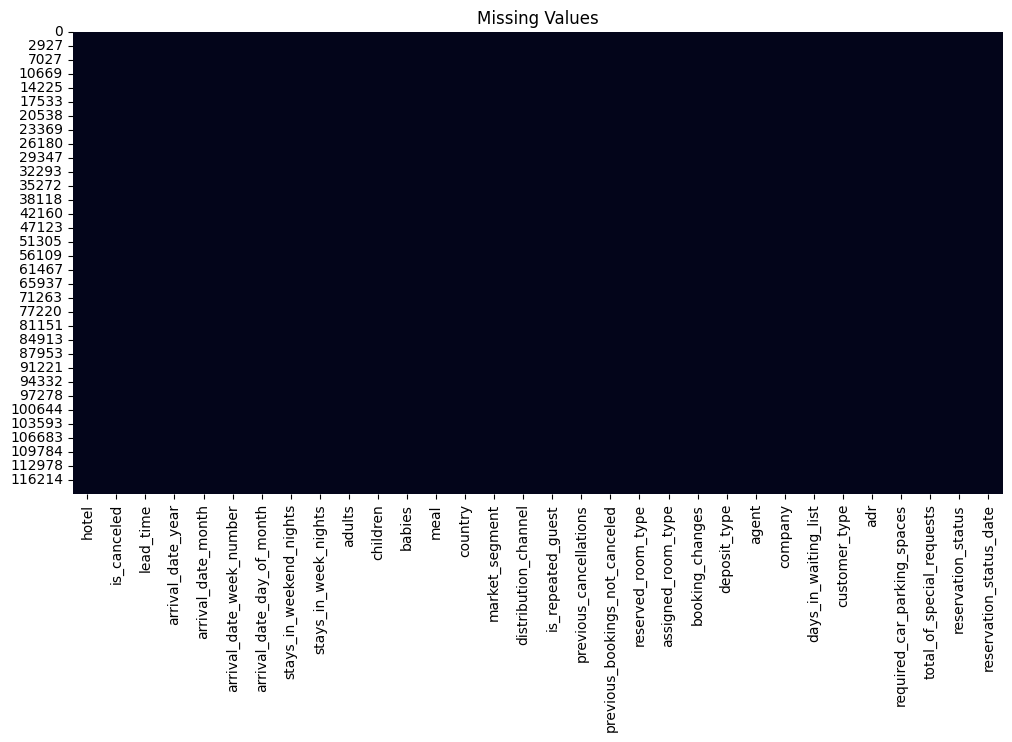

In [84]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),cbar=False)

plt.title("Missing Values")

plt.show()

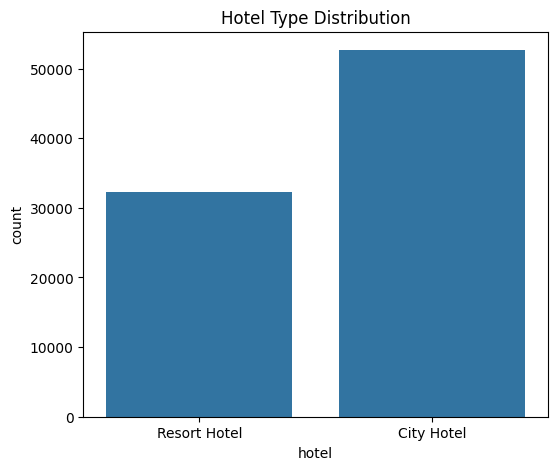

In [85]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x='hotel')

plt.title("Hotel Type Distribution")

plt.show()

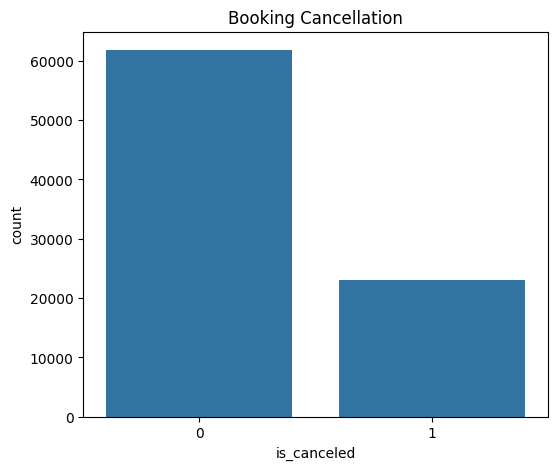

In [86]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x='is_canceled')

plt.title("Booking Cancellation")

plt.show()

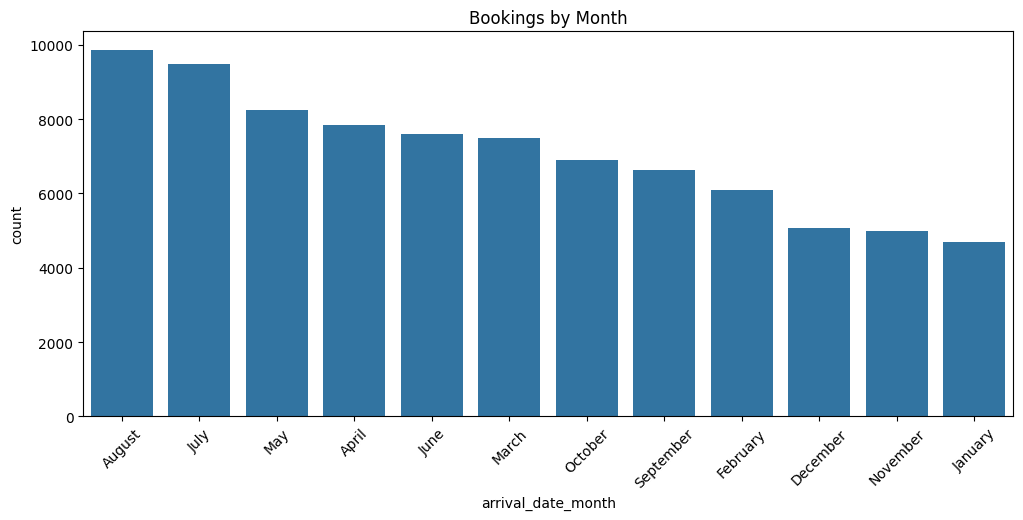

In [87]:
plt.figure(figsize=(12,5))

sns.countplot(data=df,
              x='arrival_date_month',
              order=df['arrival_date_month'].value_counts().index)

plt.xticks(rotation=45)

plt.title("Bookings by Month")

plt.show()

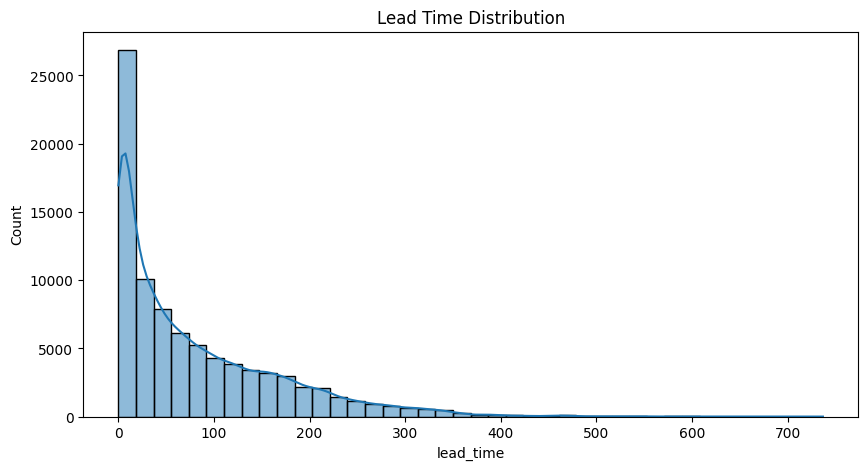

In [88]:
plt.figure(figsize=(10,5))

sns.histplot(df['lead_time'],bins=40,kde=True)

plt.title("Lead Time Distribution")

plt.show()

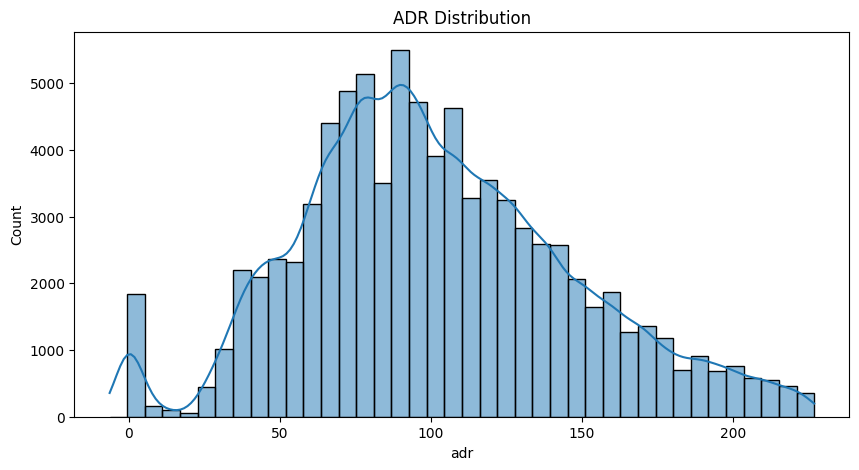

In [89]:
plt.figure(figsize=(10,5))

sns.histplot(df['adr'],bins=40,kde=True)

plt.title("ADR Distribution")

plt.show()


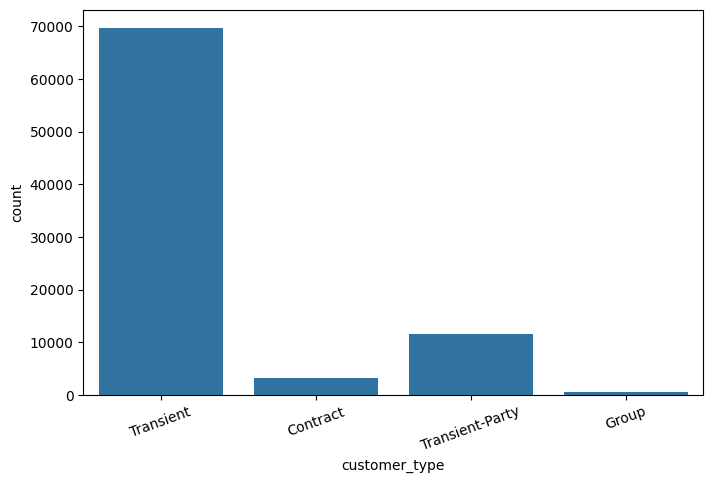

In [90]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x='customer_type')

plt.xticks(rotation=20)

plt.show()

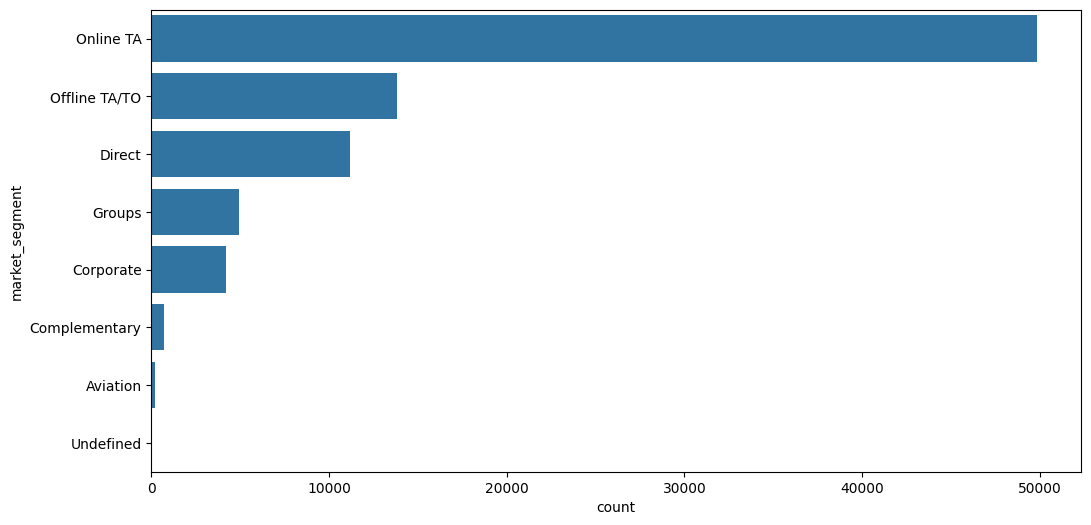

In [91]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,
              y='market_segment',
              order=df['market_segment'].value_counts().index)

plt.show()

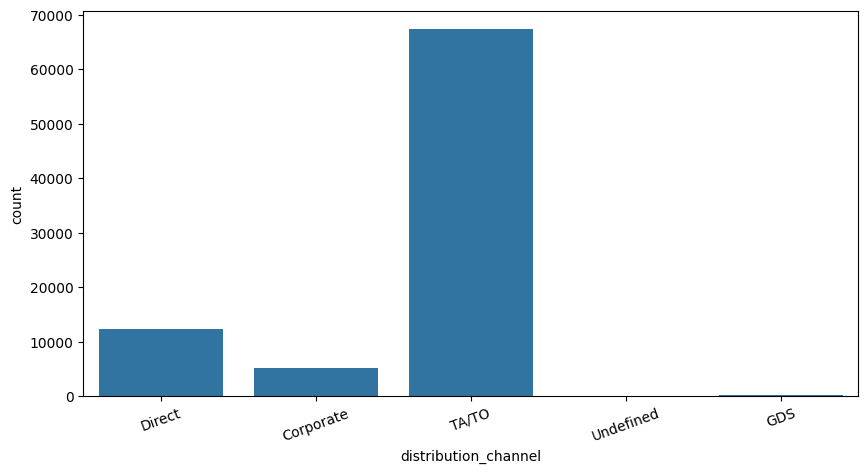

In [92]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x='distribution_channel')

plt.xticks(rotation=20)

plt.show()

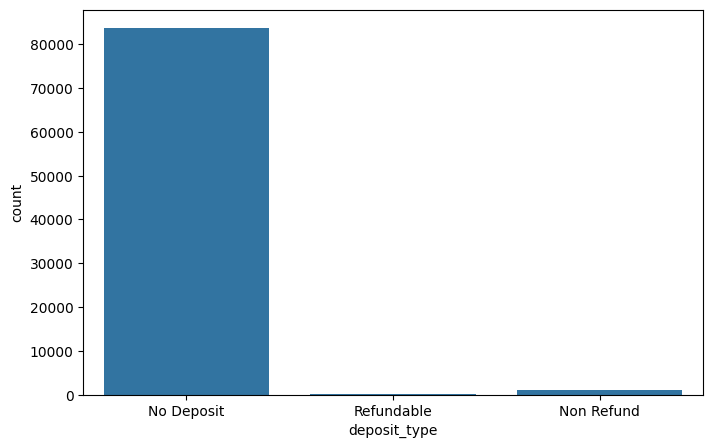

In [93]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x='deposit_type')

plt.show()

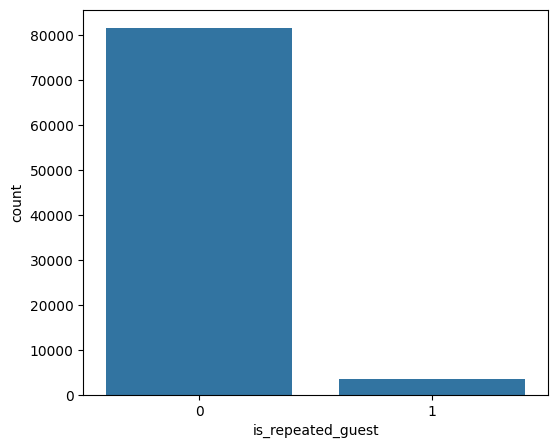

In [94]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x='is_repeated_guest')

plt.show()

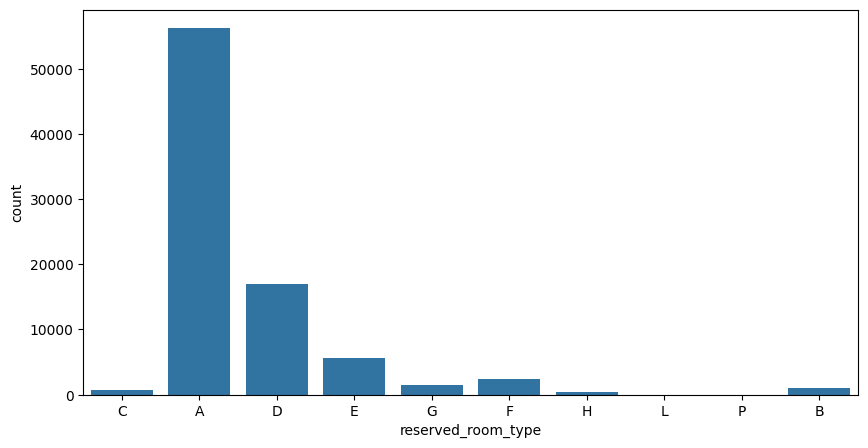

In [95]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,x='reserved_room_type')

plt.show()

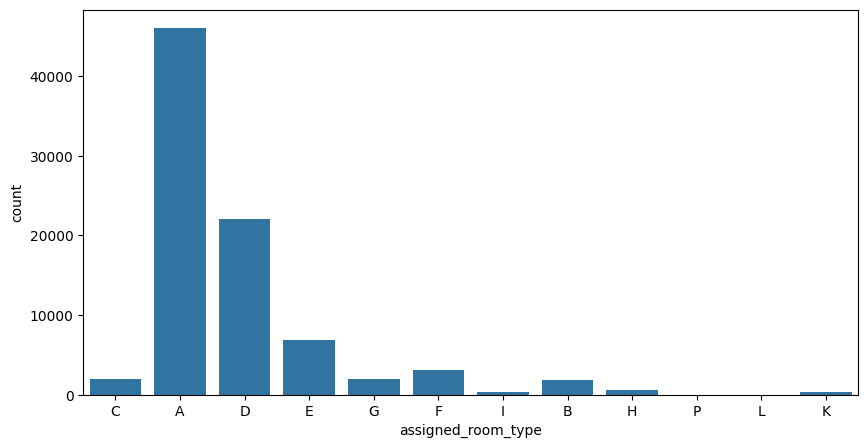

In [96]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,x='assigned_room_type')

plt.show()

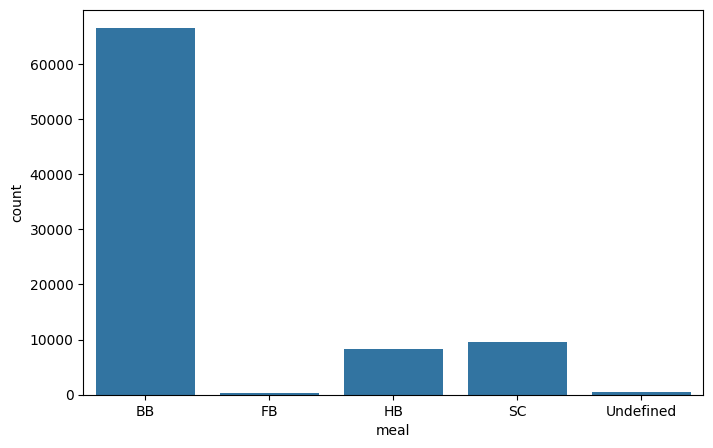

In [97]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x='meal')

plt.show()

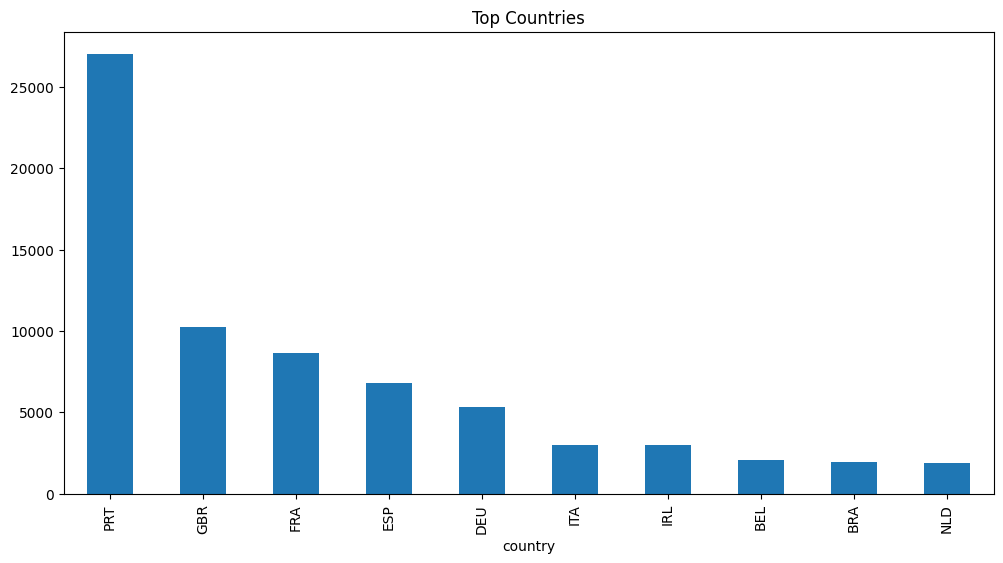

In [98]:
plt.figure(figsize=(12,6))

df['country'].value_counts().head(10).plot(kind='bar')

plt.title("Top Countries")

plt.show()

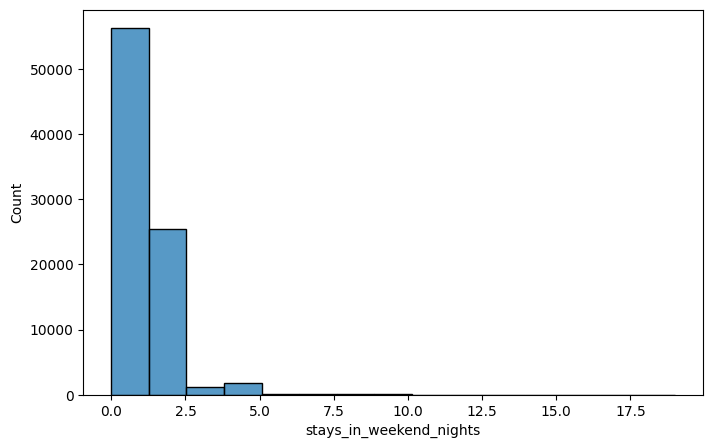

In [99]:
plt.figure(figsize=(8,5))

sns.histplot(df['stays_in_weekend_nights'],bins=15)

plt.show()


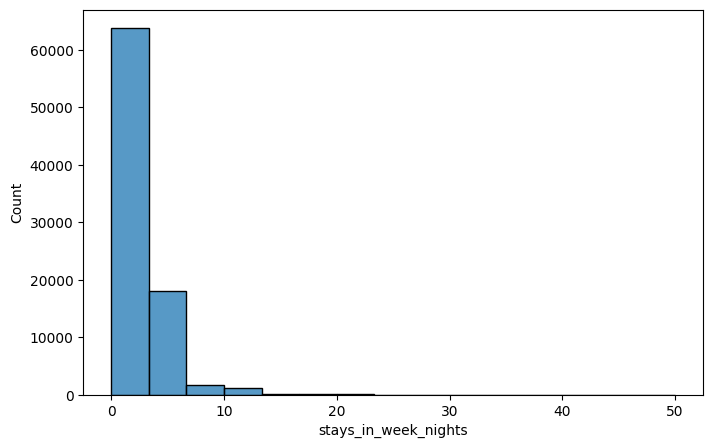

In [100]:
plt.figure(figsize=(8,5))

sns.histplot(df['stays_in_week_nights'],bins=15)

plt.show()

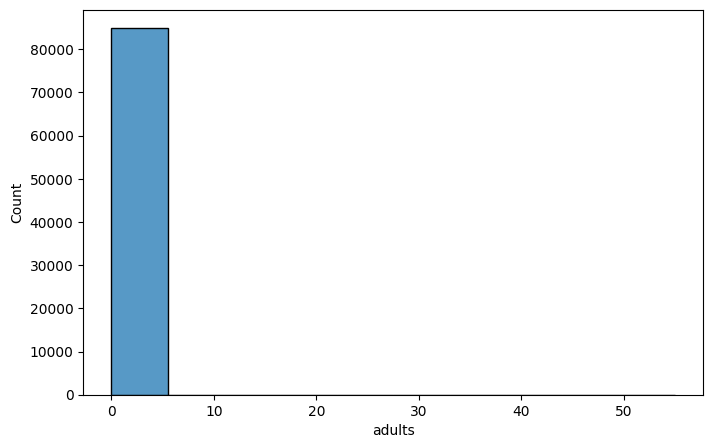

In [101]:
plt.figure(figsize=(8,5))

sns.histplot(df['adults'],bins=10)

plt.show()

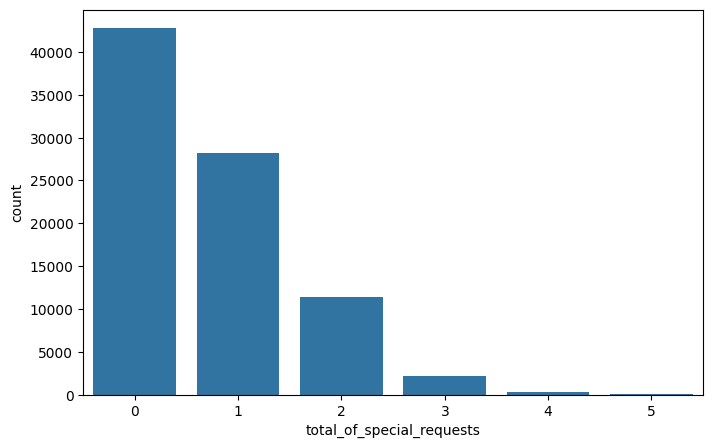

In [102]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x='total_of_special_requests')

plt.show()

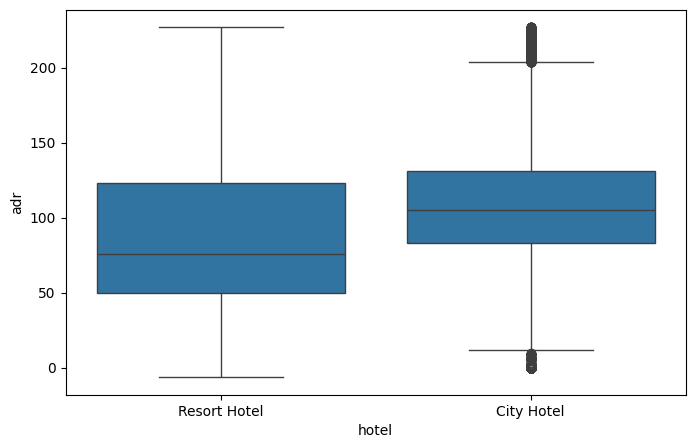

In [103]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x='hotel',
            y='adr')

plt.show()

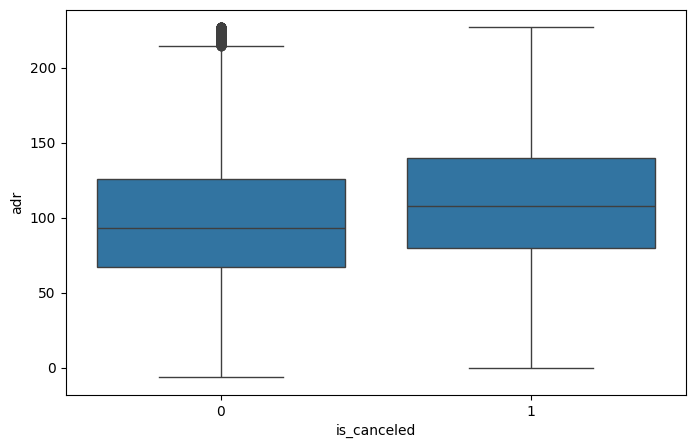

In [104]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x='is_canceled',
            y='adr')

plt.show()

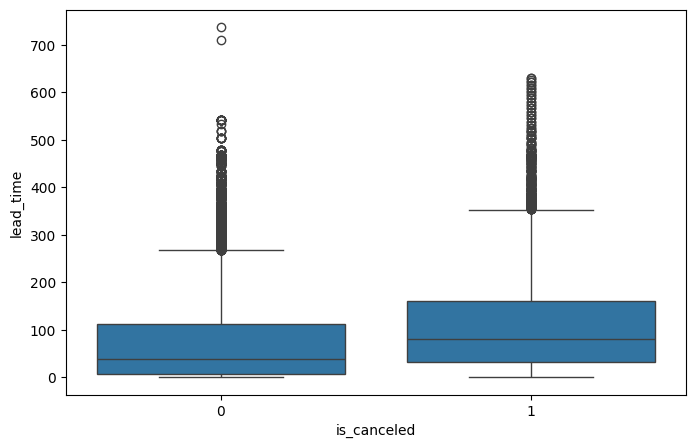

In [105]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x='is_canceled',
            y='lead_time')

plt.show()

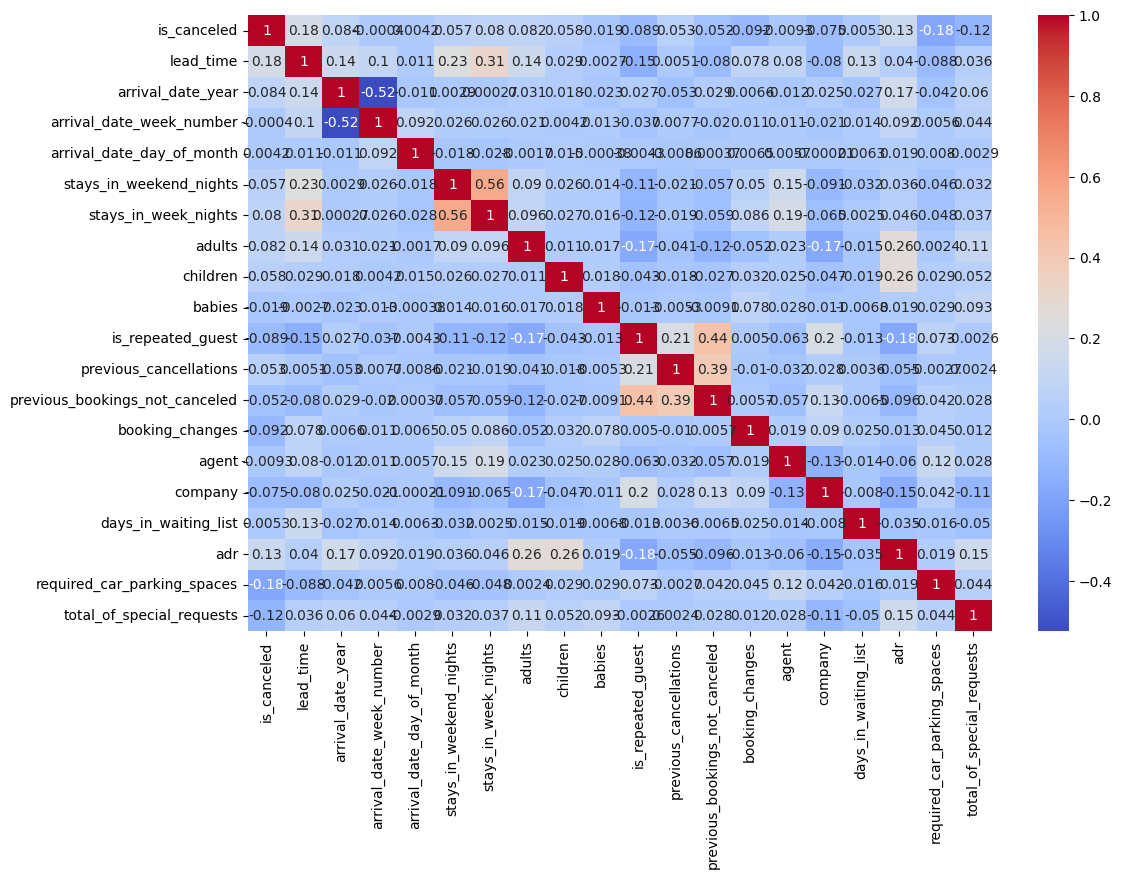

In [106]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

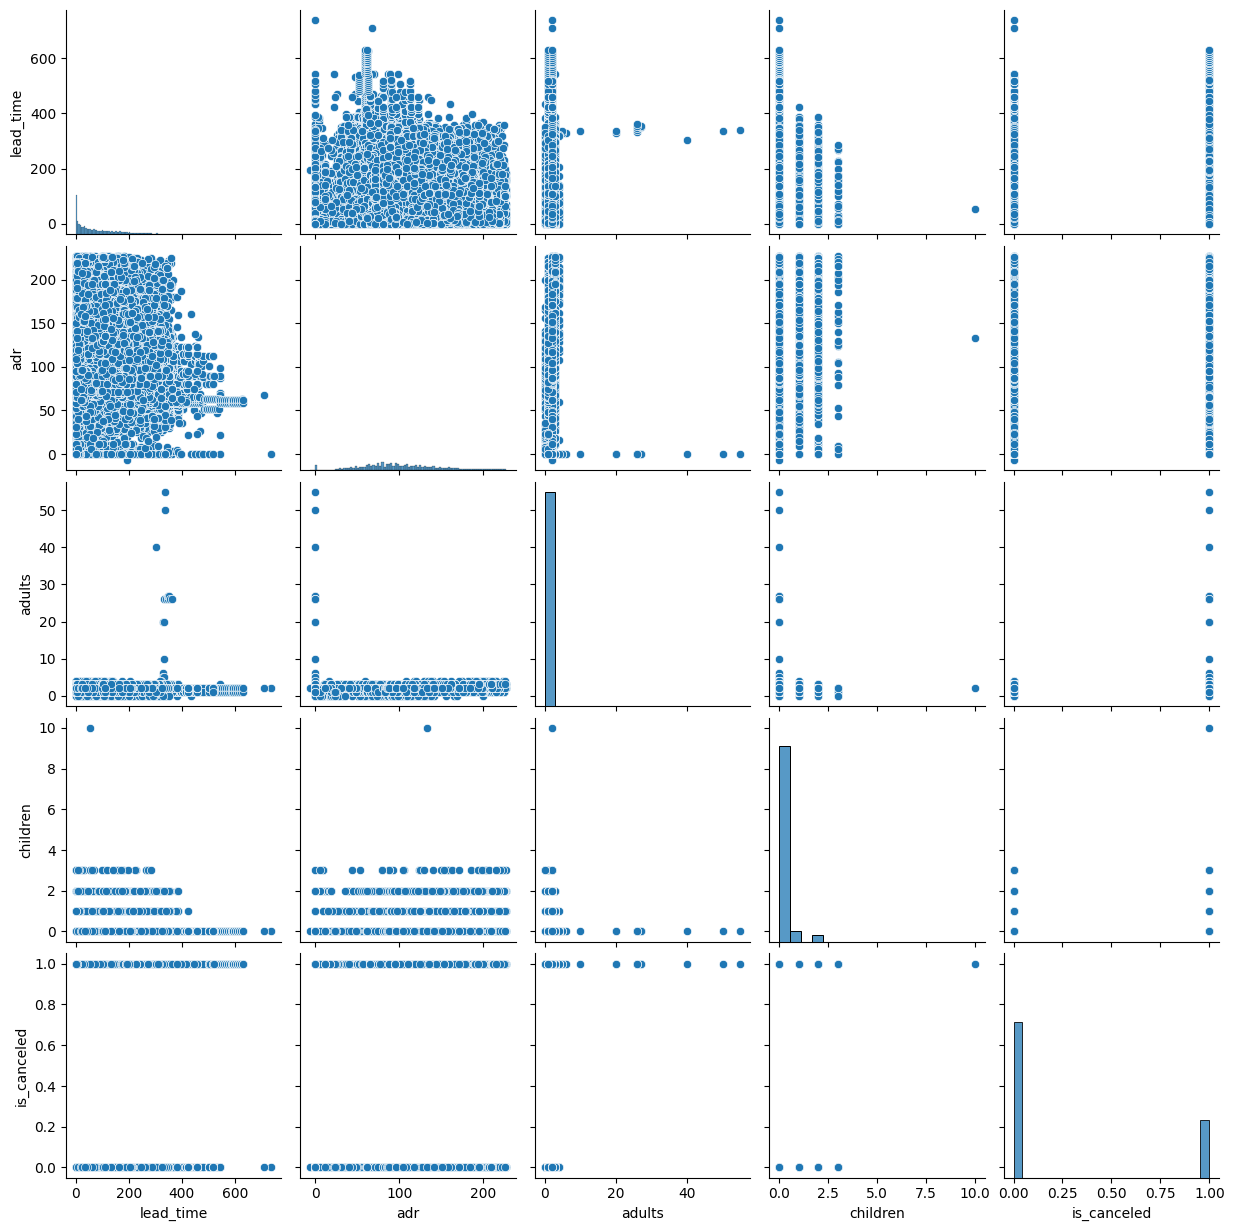

In [107]:
sns.pairplot(df[['lead_time',
                 'adr',
                 'adults',
                 'children',
                 'is_canceled']])

plt.show()

In [108]:
df.to_csv("hotel_bookings_cleaned.csv", index=False)

print("✅ Cleaned dataset saved successfully!")


✅ Cleaned dataset saved successfully!


In [109]:
from google.colab import files

files.download("hotel_bookings_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>